In [3]:
# Importando as livrarias necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import py7zr
import tempfile
from urllib import request
import re
import unicodedata

In [4]:
# Definindo uma função que lê e extrai os arquivos do servidor ftp e armazena em um DataFrame pandas
def extract_rais_files(url, nrows=None, cols=None):
    """
    Comportamento:
        Esta função acessa e extrai conjunto de dados RAIS de um servidor ftp
        do Ministério do Trabalho e armazena temporariamente em diretório local para
        posteriormente disponibilizar em um DataFrame pandas para futuras explorações.

    Parâmetros:
        url: path. Recebe o caminho do arquivo
        nrows: int. Default é None. A quantidade de linhas do data set a set importado.
        cols: list-like. Default é None. Recebe colunas específicas a serem importadas
    
    Retorna: 
        pandas.DataFrame. Retorna um DataFrame pandas
    """
    
    # Lê os dados do servidor ftp
    with request.urlopen(url) as file:
        file_content = file.read()
    
    # Cria um diretório temporário local para armazenar os dados
    with tempfile.TemporaryDirectory() as temp_dir:
        path_file_7z = os.path.join(temp_dir, "temp_file.7z")
        with open(path_file_7z, mode="wb") as f:
            f.write(file_content)

        # Descompacta os arquivos 7z
        with py7zr.SevenZipFile(path_file_7z, mode="r") as z:
            z.extractall(path=temp_dir)

        # Armazena os arquivos descompactados em uma variável `csv_path`
        extracted_file = os.listdir(temp_dir)
        csv_path = None

        # Itera sobre os arquivos descompactados em busca de arquivo csv
        for file_name in extracted_file:
            full_path = os.path.join(temp_dir, file_name)

            try:
                pd.read_csv(full_path, sep=";", nrows=5, encoding="ISO-8859-1")
                csv_path = full_path
                break
            except Exception:
                continue
        
        if not csv_path:
            raise FileNotFoundError("Nenhum arquivo csv foi encontrado no arquivo 7z.")

        # Lê os dados em um DataFrame com diferentes tentativas de condificações
        try:
            df = pd.read_csv(csv_path, sep=";", header=0, encoding="UTF-8", nrows=nrows, usecols=cols)
        
        except UnicodeDecodeError:
            df = pd.read_csv(csv_path, sep=";", header=0, encoding="ISO-8859-1", nrows=nrows, usecols=cols)
        
    return df

Normalmente os arquivos RAIS são muito grandes, vários Gygabytes, então por conveniência e por performance vamos importar somente as variáveis desejadas diretamente pelo parâmetro `cols` da função `extract_rais_files()`

In [5]:
# Cria uma lista com apenas as variáveis desejadas:
cols = [
    "Faixa Etária", "Escolaridade após 2005",
    "Município", "Raça Cor", "Faixa Remun Média (SM)",
    "Sexo Trabalhador", "IBGE Subsetor", "Faixa Hora Contrat",
    "Causa Afastamento 1", "Causa Afastamento 2", "Causa Afastamento 3",
    "Motivo Desligamento", "Tipo Vínculo", "CBO Ocupação 2002", "CNAE 2.0 Classe",
    "CNAE 2.0 Subclasse"
]

In [6]:
# Chama a função e passa os argumentos
df = extract_rais_files(url="ftp://ftp.mtps.gov.br/pdet/microdados/RAIS/2024/RAIS_VINC_PUB_SP.7z", cols=cols)

# Visualiza as primeiras observações do dataset
df.head(10)

,Causa Afastamento 1,Causa Afastamento 2,Causa Afastamento 3,Motivo Desligamento,CBO Ocupação 2002,CNAE 2.0 Classe,Faixa Etária,Faixa Hora Contrat,Faixa Remun Média (SM),Escolaridade após 2005,Município,Raça Cor,CNAE 2.0 Subclasse,Sexo Trabalhador,Tipo Vínculo,IBGE Subsetor
0,40,99,99,60,782510,49302,8,6,98,1,353870,2,4930202,1,10,20
1,99,99,99,11,724110,41204,6,6,98,1,355030,2,4120400,1,10,15
2,40,99,99,21,848510,47229,7,6,98,1,353440,2,4722901,1,10,16
3,99,99,99,21,641015,1318,4,6,1,1,354805,8,131800,1,20,25
4,99,99,99,21,622505,1318,3,6,98,1,354805,4,131800,1,20,25
5,99,99,99,11,514320,78108,3,99,98,1,354850,8,7810800,1,10,19
6,99,99,99,11,717020,43223,3,6,98,1,355030,2,4322301,1,10,15
7,99,99,99,11,622020,1334,4,6,98,1,352610,9,133402,1,10,25
8,99,99,99,11,517410,81125,8,6,98,1,355030,2,8112500,1,10,19
9,99,99,99,12,513405,55108,6,6,1,1,355540,2,5510801,1,60,21


In [7]:
# Normalizando labels, removendo ascentos
def clean_names(nome: str)-> str:
    
    """Coloca os labels das variáveis em lowercase, substitui espaçoes vazios e caracteres não alphanumericos por underscore (_)."""
    
    print("Annotations:", clean_names.__annotations__)

    nome = nome.lower().strip()
    nome = nome.replace("ç", "c")
    nome = unicodedata.normalize("NFD", nome)
    nome = nome.encode("ascii", "ignore").decode("utf-8")
    nome = re.sub(r"[^a-z0-9]+", "_", nome,)
    if nome and nome[0].isdigit():
        nome = "col_" + nome
    
    return nome

In [8]:
# Aplicando a função de normalização dos labels das variáveis
df.columns = [clean_names(col) for col in df.columns]

df.head(10)

Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}
Annotations: {'nome': <class 'str'>, 'return': <class 'str'>}


,causa_afastamento_1,causa_afastamento_2,causa_afastamento_3,motivo_desligamento,cbo_ocupacao_2002,cnae_2_0_classe,faixa_etaria,faixa_hora_contrat,faixa_remun_media_sm_,escolaridade_apos_2005,municipio,raca_cor,cnae_2_0_subclasse,sexo_trabalhador,tipo_vinculo,ibge_subsetor
0,40,99,99,60,782510,49302,8,6,98,1,353870,2,4930202,1,10,20
1,99,99,99,11,724110,41204,6,6,98,1,355030,2,4120400,1,10,15
2,40,99,99,21,848510,47229,7,6,98,1,353440,2,4722901,1,10,16
3,99,99,99,21,641015,1318,4,6,1,1,354805,8,131800,1,20,25
4,99,99,99,21,622505,1318,3,6,98,1,354805,4,131800,1,20,25
5,99,99,99,11,514320,78108,3,99,98,1,354850,8,7810800,1,10,19
6,99,99,99,11,717020,43223,3,6,98,1,355030,2,4322301,1,10,15
7,99,99,99,11,622020,1334,4,6,98,1,352610,9,133402,1,10,25
8,99,99,99,11,517410,81125,8,6,98,1,355030,2,8112500,1,10,19
9,99,99,99,12,513405,55108,6,6,1,1,355540,2,5510801,1,60,21


A análise tem o objetivo de verificar os dados apenas dos trabalhadores da cidade de São Paulo, então vamos fazer esse filtro. Nos manuais oficiais, a cidade de São Paulo é identificada pelo código simplificado `355030`.

In [9]:
# Selecionando apenas os dados da cidade de São Paulo
df_sp = df.query("municipio == 355030").copy()

df_sp.head()

,causa_afastamento_1,causa_afastamento_2,causa_afastamento_3,motivo_desligamento,cbo_ocupacao_2002,cnae_2_0_classe,faixa_etaria,faixa_hora_contrat,faixa_remun_media_sm_,escolaridade_apos_2005,municipio,raca_cor,cnae_2_0_subclasse,sexo_trabalhador,tipo_vinculo,ibge_subsetor
1,99,99,99,11,724110,41204,6,6,98,1,355030,2,4120400,1,10,15
6,99,99,99,11,717020,43223,3,6,98,1,355030,2,4322301,1,10,15
8,99,99,99,11,517410,81125,8,6,98,1,355030,2,8112500,1,10,19
22,99,99,99,21,517410,81117,7,6,98,1,355030,8,8111700,1,60,19
23,99,99,99,11,715525,41204,3,6,98,1,355030,8,4120400,1,10,15


A base de dados se encontra com as observações em códigos numéricos para representar os dados categóricos, — Esse é o padrão das bases de dados da RAIS — isso dificulta o entendimento na análise exploratória, então será realizado o mapeamento destes códigos e inferência do seus respectivos valores categóricos.

Observação:

No layout da RAIS informa que caso os códigos 12, 98, 99 sejam encontrados, podem ser ignorados, após realizar realizar uma busca nos manuais e tabelas oficiais, não foram encontrados os valores categóricos dos códigos citados , nem da RAIS e nem do e-social, por tanto, optei por descartá-los nesta análise.

Todos esses materiais de apoio como manuais e tableas oficiais podem ser acessados através dos links [RAIS](http://www.rais.gov.br/sitio/sobre.jsf), [MTE/RAIS](https://www.gov.br/trabalho-e-emprego/pt-br/assuntos/estatisticas-trabalho/rais/rais-2024) e [esocial-tabelas](https://www.gov.br/esocial/pt-br/tabelas-do-esocial), [esocial-manuais](https://www.gov.br/esocial/pt-br/documentacao-tecnica).

Para Acessar o layout que menciona a informação de ignorar os códigos acima, siga as instruções no site do Ministério do Trabalho neste [link](https://www.gov.br/trabalho-e-emprego/pt-br/assuntos/estatisticas-trabalho/microdados-rais-e-caged). É o mesmo link onde são encontrados os microdados. O arquivo está dentro da  pasta microdados/RAIS/Layouts.

In [11]:
# Removendo linhas onde temos as observações 9, 12, 98, 99
df_sp = df_sp[~(df_sp.isin([-1, 9,12,98,99]).any(axis=1))]

# Identidicando número de linhas e variáveis que possui o nosso dataset:
df_sp.shape

(283108, 16)

Nossa dataset agora após a filtragem dos items de interesse, possui 16 variáveis
e 283.108 linhas. Agora vamos começar o mapeamento dos dados categóricos.

In [23]:
# Mapeando os códigos e seus respectivos significados
sexo_map = {
    1: "masculino",
    2: "feminino",
}

# Raça cor:
cor = {
    1: "indígina",
    2: "branca",
    4: "preta",
    6: "amarela",
    8: "parda",
}

# Faixa etária
faixa_etaria_dict = {
    3: "18 a 24 anos",
	7: "50 a 64 anos",
	1: "10 a 14 anos",
	4: "25 a 29 anos",
	5: "30 a 39 anos",
	6: "40 a 49 anos",
	2: "15 a 17 anos",
	8: "65 anos ou mais"
}

# Faixa de escolaridade
escolaridade = {
    10: "mestrado",
    1: "analfabeto",
    6: "médio incompleto",
    8: "superior incompleto",
    7: "médio completo",
    3: "5.A fundamental completo",
    4: "5 A 9 fundamental",
    2: "até 5 A incompleto",
    9: "superior completo",
    11: "doutorado",
    5: "fundamental completo"
}

# Faixa média salarial (salário mínimo)
media_salarial = {
    4: "2,01 a 3,00 salários mínimos",
    11: "mais de 20,00 salários mínimos",
    6: "4,01 a 5,00 salários mínimos",
    9: "10,01 a 15,00 salários mínimos",
    7: "5,01 a 7,00 salários mínimos",
	2: "1,01 a 1,50 salários mínimos",
	3: "1,51 a 2,00 salários mínimos",
	5: "3,01 a 4,00 salários mínimos",
	8: "7,01 a 10,00 salários mínimos",
	10: "Entre 15,01 e 20,00 salários mínimos",
	1: "0,51 a 1,00 salários mínimos",
	0: "0,50 salários mínimos ou menos"

}


In [24]:
# Criando novas colunas com os valores categóricos inferidos
df_sp["sexo_trabalhador_mapped"] = df_sp["sexo_trabalhador"].map(sexo_map)

df_sp["escolaridade_apos_2005_mapped"] = df_sp["escolaridade_apos_2005"].map(escolaridade)

df_sp["faixa_etaria_mapped"] = df_sp["faixa_etaria"].map(faixa_etaria_dict)

df_sp["faixa_remun_media_sm_mapped"] = df_sp["faixa_remun_media_sm_"].map(media_salarial)

df_sp["raca_cor_mapped"] = df_sp["raca_cor"].map(cor)

df_sp.head()

,causa_afastamento_1,causa_afastamento_2,causa_afastamento_3,motivo_desligamento,cbo_ocupacao_2002,cnae_2_0_classe,faixa_etaria,faixa_hora_contrat,faixa_remun_media_sm_,escolaridade_apos_2005,...,raca_cor,cnae_2_0_subclasse,sexo_trabalhador,tipo_vinculo,ibge_subsetor,sexo_trabalhador_mapped,escolaridade_apos_2005_mapped,faixa_etaria_mapped,faixa_remun_media_sm_mapped,raca_cor_mapped
1154,40,40,40,11,717020,43223,5,6,2,1,...,2,4322301,1,10,15,masculino,analfabeto,30 a 39 anos,"1,01 a 1,50 salários mínimos",branca
1159,40,40,40,11,717020,43223,7,6,2,1,...,2,4322301,1,10,15,masculino,analfabeto,50 a 64 anos,"1,01 a 1,50 salários mínimos",branca
1191,40,40,40,11,715210,41204,7,6,2,1,...,2,4120400,1,10,15,masculino,analfabeto,50 a 64 anos,"1,01 a 1,50 salários mínimos",branca
1291,40,40,40,11,717020,43304,5,6,2,1,...,8,4330404,1,10,15,masculino,analfabeto,30 a 39 anos,"1,01 a 1,50 salários mínimos",parda
1448,40,40,40,21,517410,81117,6,6,2,1,...,4,8111700,1,10,19,masculino,analfabeto,40 a 49 anos,"1,01 a 1,50 salários mínimos",preta


Agora que o dataset está filtrado apenas com os dados da cidade, variáveis desejadas e com os valores categóricos inferidos, podemos explorar a base de dados e obter alguns informações.

In [14]:
# Analisando a estrutura do dataset, considerando apenas as novas variáveis:
df_sp.iloc[:, 16:21].info()

<class 'pandas.core.frame.DataFrame'>
Index: 283108 entries, 1154 to 22466980
Data columns (total 5 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   sexo_trabalhador_mapped        283108 non-null  object
 1   escolaridade_apos_2005_mapped  283108 non-null  object
 2   faixa_etaria_mapped            283108 non-null  object
 3   faixa_remun_media_sm_mapped    283108 non-null  object
 4   raca_cor_mapped                283108 non-null  object
dtypes: object(5)
memory usage: 13.0+ MB


5 variáveis tiveram seus códigos inferidos com valores categóricos, e o dataset possui 283108 linhas e não constam dados faltantes. Todas as variáveis são do tipo objeto.

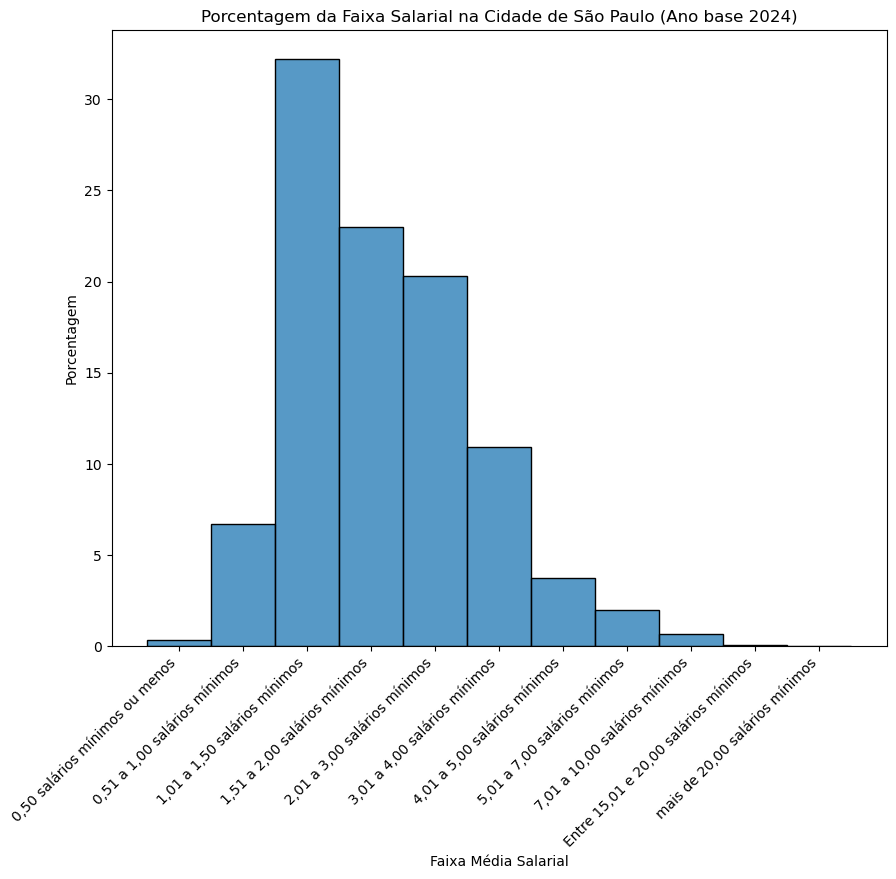

In [25]:
# Distribuição de frequência da faixa média salarial
plt.figure(figsize=(10, 8))
plt.plot()

sns.histplot(
    x=df_sp["faixa_remun_media_sm_mapped"].sort_values(),
    stat="percent"
)

plt.title("Porcentagem da Faixa Salarial na Cidade de São Paulo (Ano base 2024)")
plt.xlabel("Faixa Média Salarial")
plt.ylabel("Porcentagem")
plt.xticks(rotation=45, horizontalalignment="right")
plt.show()


Encontramos que existe uma distribuição assimétrica positiva, visto que a calda 
do histograma se projeta mais a direita, onde se encontram os maiores salários. 
A maior frequência é de quem recebe entre 1 e 1,5 salários mínimos, aproximadamente 
35% dos trabalhadores, já 25% e 20% são dos que recebem entre 1,5 a 2,0 e 2,0 a 3,0
salários mínimos. 

Observe que nos dois extremos do gráfico, aproximadamente 1% sáo dos que recebem  
recebem até 0,5 salários mínimos (No extremo esquerdo) e mais de 20,00 salários
mínimos (extremo direito).

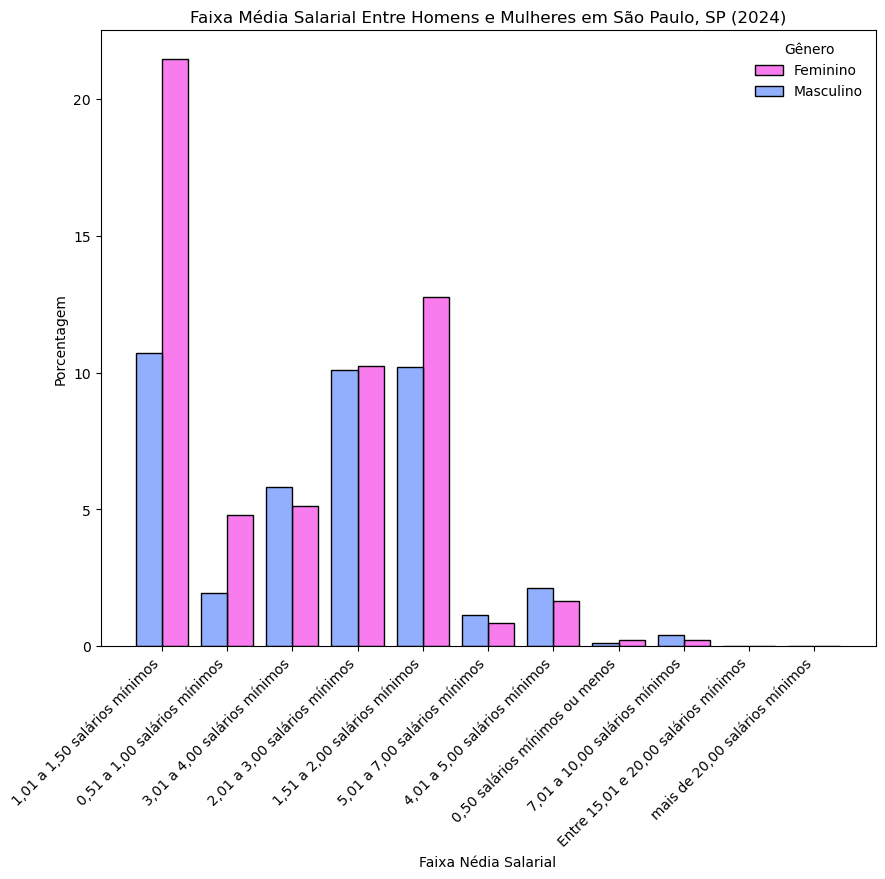

In [ ]:
# Vamos verificar essa distribuição entre homens e mulheres:
plt.figure(figsize=(10, 8))
sns.histplot(
    x=df_sp["faixa_remun_media_sm_mapped"].sort_values(),
    stat="percent",
    hue=df_sp["sexo_trabalhador_mapped"],
    multiple="dodge", 
    shrink=.8,
    palette={"masculino": "#628EFC", "feminino": "#F745E9"},
    alpha = 0.7,
)

plt.title("Faixa Média Salarial Entre Homens e Mulheres em São Paulo, SP (2024)")
plt.xlabel("Faixa Média Salarial")
plt.ylabel("Porcentagem")
plt.xticks(rotation=45, horizontalalignment="right")
plt.legend(
    title = "Gênero",
    labels = ["Feminino", "Masculino"],
    frameon = False
)

Na divisão por grupo entre homens e mulheres, as mulheres tendem a ter uma maior
frequência quando a faixa salarial média é menor, a medida que essa faixa salarial 
média vai aumentado, os homens tendem a ter uma maior predominância.

(0.0, 1.0)

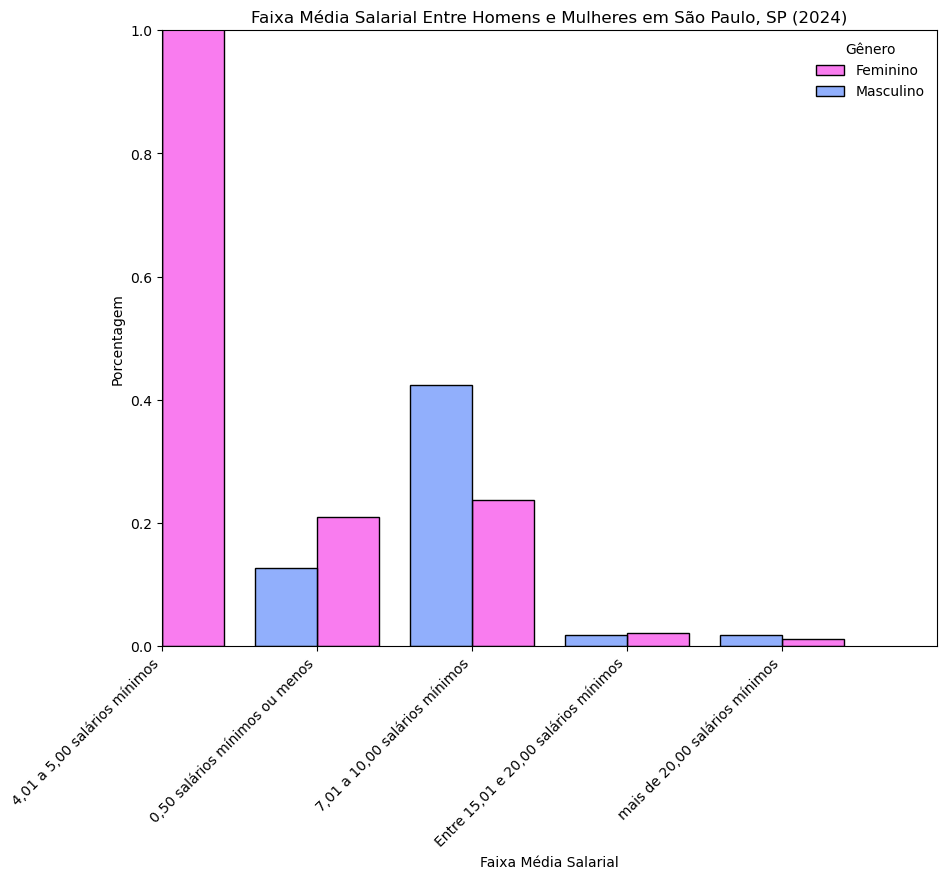

In [47]:
# Vamos analisar as maiores rendas, pois não foi possível visualizar no gráfico anterior:
plt.figure(figsize=(10, 8))
sns.histplot(
    x=df_sp["faixa_remun_media_sm_mapped"].sort_values(),
    stat="percent",
    hue=df_sp["sexo_trabalhador_mapped"],
    multiple="dodge", 
    shrink=.8,
    palette={"masculino": "#628EFC", "feminino": "#F745E9"},
    alpha = 0.7,
)

plt.title("Faixa Média Salarial Entre Homens e Mulheres em São Paulo, SP (2024)")
plt.xlabel("Faixa Média Salarial")
plt.ylabel("Porcentagem")
plt.xticks(rotation=45, horizontalalignment="right")
plt.legend(
    title = "Gênero",
    labels = ["Feminino", "Masculino"],
    frameon = False
)
plt.xlim(6, 11)
plt.ylim(0, 1)

No gráfico acima foi realizado um zoom para conseguirmos visualizar melhor a diferença
entre as duas categorias. Nos  maiores salários, especificamente quem ganha mais
de 15 salários mínimos, a diferença é muito pequena, mais no geral, a categoria
feminia ainda possui uma frequência menor quando falamos de maiores salários.

In [50]:
df_sp.iloc[:, 16:].head()

,sexo_trabalhador_mapped,escolaridade_apos_2005_mapped,faixa_etaria_mapped,faixa_remun_media_sm_mapped,raca_cor_mapped
1154,masculino,analfabeto,30 a 39 anos,"1,01 a 1,50 salários mínimos",branca
1159,masculino,analfabeto,50 a 64 anos,"1,01 a 1,50 salários mínimos",branca
1191,masculino,analfabeto,50 a 64 anos,"1,01 a 1,50 salários mínimos",branca
1291,masculino,analfabeto,30 a 39 anos,"1,01 a 1,50 salários mínimos",parda
1448,masculino,analfabeto,40 a 49 anos,"1,01 a 1,50 salários mínimos",preta


Text(0, 0.5, 'Faixa Salarial Média')

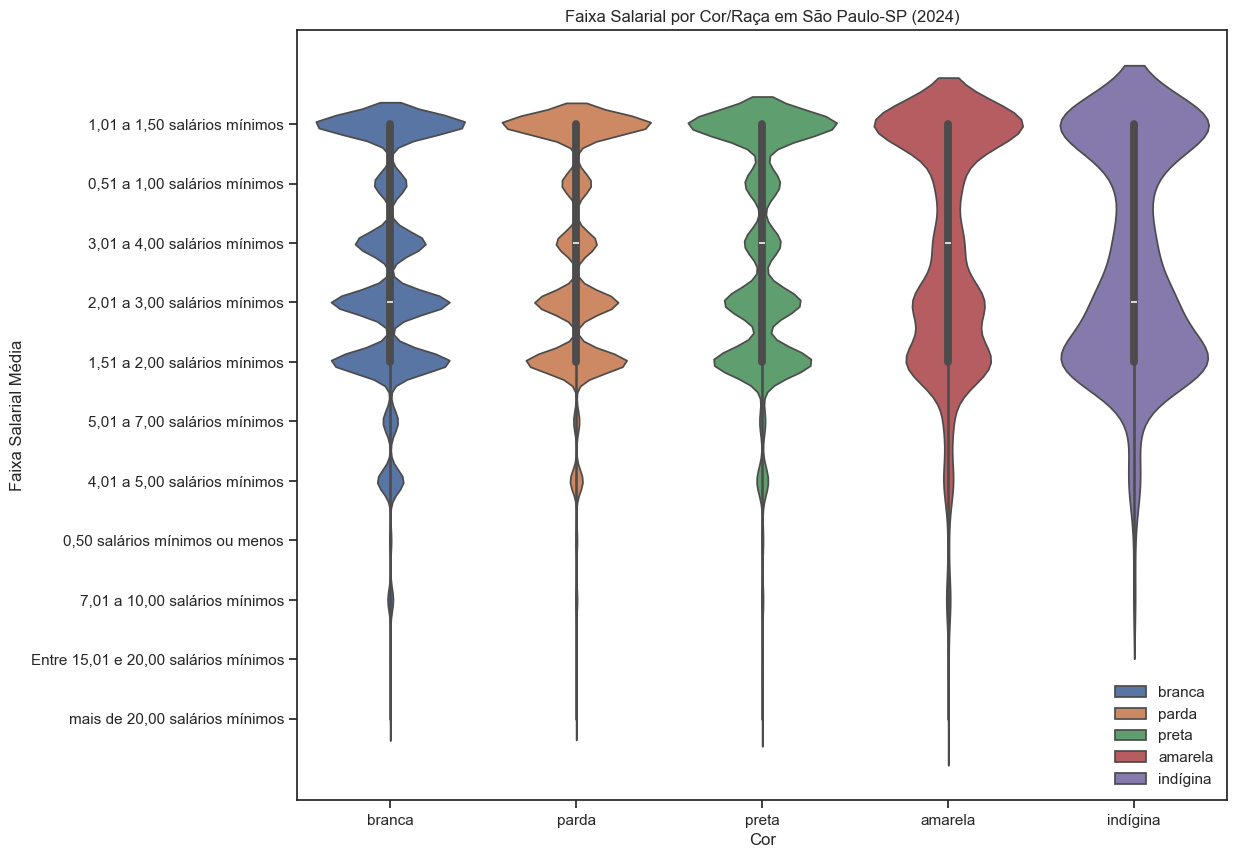

In [84]:
# Distribuição de frequência da Faixa média salarial entre as etnias:
plt.figure(figsize=(12, 10))
sns.set_theme(style="ticks")

sns.violinplot(
   df_sp,
   x="raca_cor_mapped",
   y="faixa_remun_media_sm_mapped",
   hue="raca_cor_mapped",
   legend=True, 
)
plt.legend(
    title=None,
    frameon=False
)

plt.title("Faixa Salarial por Cor/Raça em São Paulo-SP (2024)")
plt.xlabel("Cor")
plt.ylabel("Faixa Salarial Média")

No gráfico de violino conseguimos ver melhor a densidade das observações dentro
de cada categoria. No categoria indígina, aparentemente não há observações com 
faixa salarial média de mais de 20 salários mínimos, mas isso é algo que pode ser 
investigado posteriormente.
Ainda nesta categoria, há uma maior densidade de dados na faixa salarial entre
1,0 a 1,5 e 1,5 a 2,0 salários mínimos.